[[ 2. -1.  0. ...  0.  0. -1.]
 [-1.  2. -1. ...  0.  0.  0.]
 [ 0. -1.  2. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  2. -1.  0.]
 [ 0.  0.  0. ... -1.  2. -1.]
 [-1.  0.  0. ...  0. -1.  2.]]


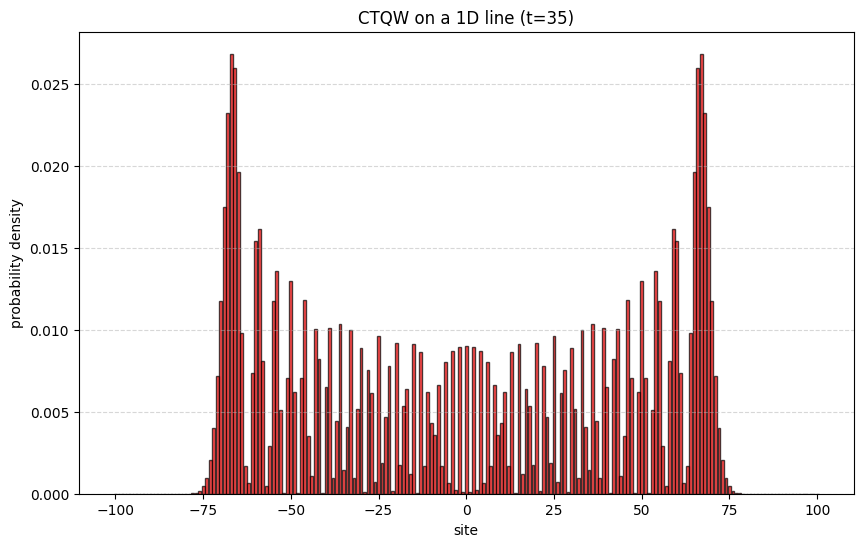

In [ ]:
import numpy as np # for doing stuff with numbers
import matplotlib.pyplot as plt # for plotting
from scipy.linalg import expm # this we need for the time evolution operator

##########################################
# 1. define parameters for a qw on a line
##########################################
half_length = 100
num_sites = 2 * half_length + 1
center = half_length
t = 35 # duration of the evolution

##########################################
# 2. Laplacian matrix for a 1D line (L = D - A)
##########################################
# on-site energies
diag = 2 * np.eye(num_sites)
# first neighbor hopping
upper_diag = -1 * np.eye(num_sites, k=1)
lower_diag = -1 * np.eye(num_sites, k=-1)
# sum
L = diag + upper_diag + lower_diag
# add periodic boundary conditions (it becomes a ring...)
L[0,-1] = -1
L[-1,0] = -1
# check 
print(L)

##########################################
# 3. initialization of the state
##########################################

psi_0 = np.zeros(num_sites, dtype=complex)
psi_0[center] = 1.0 # start at the very center

##########################################
# 4. time evolution (time-indep. H)
##########################################
gamma = 1.0 # hopping rate
H = gamma * L
U = expm(-1j * H * t) # exp(-iHt/hbar), hbar set to 1
psi_t = np.dot(U,psi_0) # matrix multiplication
#print(psi_t)

##########################################
# 5. probabilities calculation 
##########################################
probabilities = np.abs(psi_t) ** 2 
# no need to project it: this is done INTERNALLY

##########################################
# 6. plot
##########################################
positions = np.arange(-half_length, half_length+1) # this is inherently a "vector"

plt.figure(figsize=(10, 6))
plt.bar(positions, probabilities, color = 'red', edgecolor = 'black', alpha = 0.7)
plt.title(f"CTQW on a 1D line (t={t})")
plt.xlabel("site")
plt.ylabel("probability density")
plt.grid(axis='y', linestyle='--',alpha=0.5)
plt.show()

